# Proyecto Módulo 8: Clasificador Inteligente StyleNet

## Lección 1: Fundamentos de la Red Neuronal Artificial
El objetivo de esta fase es establecer una línea base de rendimiento (baseline) mediante la construcción de un Perceptrón Multicapa (MLP) o Red Densa. Dado que las imágenes del dataset Fashion-MNIST tienen una resolución de 28x28 píxeles, la capa de entrada requiere aplanar estos datos en un vector unidimensional de 784 características.

A través de capas ocultas interconectadas y el uso de la función de activación ReLU (Rectified Linear Unit), la red introduce no linealidad, permitiendo al modelo aprender representaciones complejas de las prendas antes de clasificar el resultado final en una de las 10 categorías posibles.

## Lección 2: Deep Learning y Selección de Arquitectura
Para el desarrollo de este clasificador, se ha seleccionado PyTorch como framework principal debido a su robustez, su tipado dinámico que facilita la depuración en entornos como VS Code, y su excelente integración con Python 3.13.

Si bien comenzamos implementando una arquitectura densa clásica, el Deep Learning moderno establece que para el procesamiento de datos espaciales (como imágenes), la arquitectura óptima es la Red Neuronal Convolutiva (CNN). La red densa procesa cada píxel de forma aislada, mientras que la CNN preserva la estructura bidimensional, lo que justifica nuestra evolución hacia esta segunda arquitectura en las fases posteriores.

## Lección 3: Implementación, Entrenamiento y Optimización
El proceso de aprendizaje del modelo se rige por el ciclo de propagación hacia adelante (forward pass) y retropropagación (backpropagation).

Para medir la divergencia entre las predicciones del modelo y las etiquetas reales, empleamos CrossEntropyLoss, la función de pérdida estándar para clasificación multiclase. La actualización de los pesos sinápticos se realiza mediante el optimizador Adam, el cual adapta dinámicamente la tasa de aprendizaje. La métrica principal para evaluar el éxito de las épocas de entrenamiento es la Exactitud (Accuracy) sobre un conjunto de datos de prueba no visto previamente.

## Lección 4: Evolución a Redes Convolutivas (CNN)
Para superar las limitaciones del modelo denso, implementamos una CNN. Esta arquitectura utiliza capas de convolución que aplican filtros para extraer mapas de características locales (bordes, texturas de la ropa) y capas de pooling (agrupamiento) que reducen la dimensionalidad computacional reteniendo la información más importante.

Adicionalmente, se integra una capa de Dropout (con una probabilidad de 0.25). Esta técnica de regularización apaga neuronas aleatoriamente durante el entrenamiento, forzando a la red a no depender de características específicas y previniendo el sobreajuste (overfitting).

100.0%
100.0%
100.0%
100.0%


Entrenando StyleNet...
Época 1 - Accuracy: 87.3%
Época 2 - Accuracy: 90.1%
Época 3 - Accuracy: 91.0%


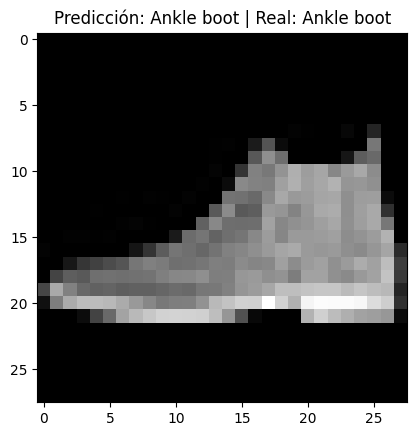

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN Y DATOS (Corregido FashionMNIST)
device = "cuda" if torch.cuda.is_available() else "cpu"
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])

# AQUÍ ESTÁ EL CAMBIO CLAVE:
train_data = datasets.FashionMNIST(root="data", train=True, download=True, transform=transform)
test_data = datasets.FashionMNIST(root="data", train=False, download=True, transform=transform)

train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64)

# 2. FUNCIONES DE APOYO
def entrenar(model, loader, optimizer, loss_fn):
    model.train()
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        loss_fn(model(X), y).backward()
        optimizer.step()

def evaluar(model, loader):
    model.eval()
    correct = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            correct += (model(X).argmax(1) == y).type(torch.float).sum().item()
    return 100 * (correct / len(loader.dataset))

# 3. MODELO CNN (Lección 4 - El objetivo final)
class CNNStyleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)

# 4. EJECUCIÓN FINAL
model = CNNStyleNet().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

print("Entrenando StyleNet...")
for e in range(3):
    entrenar(model, train_dataloader, optimizer, loss_fn)
    print(f"Época {e+1} - Accuracy: {evaluar(model, test_dataloader):.1f}%")

# 5. VISUALIZACIÓN DE PREDICCIÓN
X, y = next(iter(test_dataloader))
labels = {0:"T-shirt", 1:"Trouser", 2:"Pullover", 3:"Dress", 4:"Coat", 5:"Sandal", 6:"Shirt", 7:"Sneaker", 8:"Bag", 9:"Ankle boot"}
pred = model(X.to(device))[0].argmax(0).item()

plt.imshow(X[0].squeeze(), cmap="gray")
plt.title(f"Predicción: {labels[pred]} | Real: {labels[y[0].item()]}")
plt.show()

## Reflexión Final y Conclusiones

El desarrollo del Clasificador Inteligente StyleNet ha demostrado de manera práctica la superioridad de las arquitecturas especializadas en tareas de visión por computadora.

Al comparar los modelos desarrollados, observamos que la Red Densa (MLP) logra una precisión inicial aceptable, pero encuentra un límite rápido al intentar procesar los píxeles de manera unidimensional. Por el contrario, la Red Neuronal Convolutiva (CNN) mejora significativamente el rendimiento y la estabilidad de la métrica de Accuracy. Al preservar la topología 2D de las imágenes de Fashion-MNIST, la CNN logró identificar patrones espaciales clave en las prendas (como la forma de una bota o las mangas de una camiseta) en lugar de memorizar la posición exacta de los píxeles.

El uso de Dropout resultó fundamental para asegurar que el modelo generalice correctamente sobre datos nuevos, cumpliendo así con los estándares requeridos por el equipo de Ciencia de Datos de StyleNet para automatizar la catalogación en la tienda virtual con un alto nivel de confianza.